# Análisis exploratorio de incidencia delictiva en México

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [4]:
df = pd.read_csv('data/datos_delitos.csv', encoding='latin1')

#### Ejercicio 1: Elige 3 estados de la república y grafica una serie de tiempo de la frecuencia abosluta de homicidios dolosos de enero 2015 a julio 2019 en estas tres entidades

In [ ]:
df.head()
# df.tail()
# df.head(3)
# df.tail(3)



,Año,Clave_Ent,Entidad,Bien jurídico afectado,Tipo de delito,Subtipo de delito,Modalidad,Enero,Febrero,Marzo,Abril,Mayo,Junio,Julio,Agosto,Septiembre,Octubre,Noviembre,Diciembre
0,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma de fuego,3,0,2,1,1,1,2.0,1.0,2.0,2.0,2.0,1.0
1,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma blanca,1,1,0,0,0,1,0.0,1.0,0.0,0.0,0.0,1.0
2,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con otro elemento,0,0,2,2,3,2,0.0,1.0,2.0,0.0,0.0,0.0
3,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,No especificado,2,0,0,1,0,0,0.0,0.0,0.0,0.0,0.0,0.0
4,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio culposo,Con arma de fuego,0,0,0,0,1,0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 31360 entries, 0 to 31359
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Año                     31360 non-null  int64  
 1   Clave_Ent               31360 non-null  int64  
 2   Entidad                 31360 non-null  str    
 3   Bien jurídico afectado  31360 non-null  str    
 4   Tipo de delito          31360 non-null  str    
 5   Subtipo de delito       31360 non-null  str    
 6   Modalidad               31360 non-null  str    
 7   Enero                   31360 non-null  int64  
 8   Febrero                 31360 non-null  int64  
 9   Marzo                   31360 non-null  int64  
 10  Abril                   31360 non-null  int64  
 11  Mayo                    31360 non-null  int64  
 12  Junio                   31360 non-null  int64  
 13  Julio                   28224 non-null  float64
 14  Agosto                  28224 non-null  float64
 

In [11]:
df.Modalidad.head()

0    Con arma de fuego
1      Con arma blanca
2    Con otro elemento
3      No especificado
4    Con arma de fuego
Name: Modalidad, dtype: str

In [15]:
def limpiar_columnas(df):
        columnas_limpias = []
        for col in df.columns:
                # convertir titulos de columnas a minusculas, sin espacios ni caracteres especiales
                col = col.lower().replace(" ", "_").replace("ñ", "ni").replace(".", "").replace("á", "a").replace("é", "e").replace("í", "i").replace("ó", "o").replace("ú", "u")
                columnas_limpias.append(col)
        df.columns = columnas_limpias
        return df

limpiar_columnas(df)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 31360 entries, 0 to 31359
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   anio                    31360 non-null  int64  
 1   clave_ent               31360 non-null  int64  
 2   entidad                 31360 non-null  str    
 3   bien_juridico_afectado  31360 non-null  str    
 4   tipo_de_delito          31360 non-null  str    
 5   subtipo_de_delito       31360 non-null  str    
 6   modalidad               31360 non-null  str    
 7   enero                   31360 non-null  int64  
 8   febrero                 31360 non-null  int64  
 9   marzo                   31360 non-null  int64  
 10  abril                   31360 non-null  int64  
 11  mayo                    31360 non-null  int64  
 12  junio                   31360 non-null  int64  
 13  julio                   28224 non-null  float64
 14  agosto                  28224 non-null  float64
 

In [18]:
print("Shape: ", df.shape)

datos_long = df.melt(
    id_vars=['anio', 'clave_ent', 'entidad','tipo_de_delito', 'subtipo_de_delito', 'modalidad'],
    var_name='nombre_mes',
    value_name='frecuencia'
)

print("Shape: ", datos_long.shape)

Shape:  (31360, 19)
Shape:  (407680, 8)


In [19]:
datos_long.info()

<class 'pandas.DataFrame'>
RangeIndex: 407680 entries, 0 to 407679
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   anio               407680 non-null  int64 
 1   clave_ent          407680 non-null  int64 
 2   entidad            407680 non-null  str   
 3   tipo_de_delito     407680 non-null  str   
 4   subtipo_de_delito  407680 non-null  str   
 5   modalidad          407680 non-null  str   
 6   nombre_mes         407680 non-null  str   
 7   frecuencia         388864 non-null  object
dtypes: int64(2), object(1), str(5)
memory usage: 24.9+ MB


In [73]:
datos_long[datos_long['clave_ent'] == 15].sample(15)

,anio,clave_ent,entidad,tipo_de_delito,subtipo_de_delito,modalidad,nombre_mes,frecuencia
7671,2017,15,México,Secuestro,Secuestro,Secuestro exprés,bien_juridico_afectado,NaN
315064,2015,15,México,Falsedad,Falsedad,Falsedad,octubre,6.0
198957,2018,15,México,Lesiones,Lesiones culposas,No especificado,junio,4.0
51564,2021,15,México,Lesiones,Lesiones culposas,Con otro elemento,enero,179.0
23353,2022,15,México,Tráfico de menores,Tráfico de menores,Tráfico de menores,bien_juridico_afectado,NaN
305629,2022,15,México,Robo,Robo de ganado,Con violencia,septiembre,1.0
327523,2019,15,México,Homicidio,Homicidio culposo,Con otro elemento,octubre,0.0
151958,2023,15,México,Robo,Robo en transporte público colectivo,Sin violencia,abril,70.0
255468,2016,15,México,Otros delitos contra el patrimonio,Otros delitos contra el patrimonio,Otros delitos contra el patrimonio,agosto,13.0
246019,2023,15,México,Robo,Robo a casa habitación,Con violencia,julio,110.0


Rows after date filter: 660


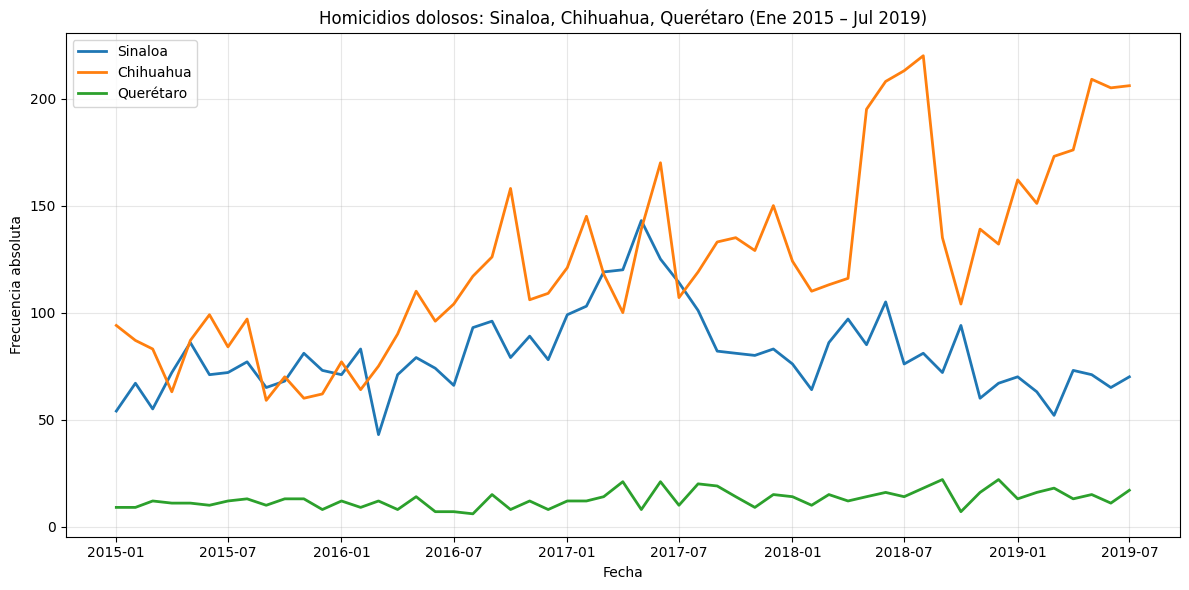

In [93]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert frecuencia to numeric
datos_long['frecuencia'] = pd.to_numeric(datos_long['frecuencia'], errors='coerce')

# Filter states and crime
estados = ['Sinaloa', 'Chihuahua', 'Querétaro']
mask = (datos_long['subtipo_de_delito'] == 'Homicidio doloso') & (datos_long['entidad'].isin(estados))
df_filtrado = datos_long[mask].copy()

# Month mapping (lowercase keys)
month_map = {
    'enero': 1, 'febrero': 2, 'marzo': 3, 'abril': 4,
    'mayo': 5, 'junio': 6, 'julio': 7, 'agosto': 8,
    'septiembre': 9, 'octubre': 10, 'noviembre': 11, 'diciembre': 12
}
df_filtrado['mes_num'] = df_filtrado['nombre_mes'].map(month_map)

# Drop rows with unmapped month names
df_filtrado = df_filtrado.dropna(subset=['mes_num'])
df_filtrado['mes_num'] = df_filtrado['mes_num'].astype(int)

# Create date column
df_filtrado['fecha'] = pd.to_datetime(
    df_filtrado['anio'].astype(str) + '-' + 
    df_filtrado['mes_num'].astype(str).str.zfill(2) + '-01',
    format='%Y-%m-%d'
)

# Filter date range
fecha_inicio = '2015-01-01'
fecha_fin = '2019-07-01'
df_rango = df_filtrado[(df_filtrado['fecha'] >= fecha_inicio) & (df_filtrado['fecha'] <= fecha_fin)]

print(f"Rows after date filter: {len(df_rango)}")

if len(df_rango) > 0:
    # Group and pivot
    ts_data = df_rango.groupby(['fecha', 'entidad'])['frecuencia'].sum().reset_index()
    pivot_ts = ts_data.pivot(index='fecha', columns='entidad', values='frecuencia').fillna(0)

    # Plot
    plt.figure(figsize=(12, 6))
    for estado in estados:
        if estado in pivot_ts.columns:
            plt.plot(pivot_ts.index, pivot_ts[estado], label=estado, linewidth=2)
    plt.title('Homicidios dolosos: Sinaloa, Chihuahua, Querétaro (Ene 2015 – Jul 2019)')
    plt.xlabel('Fecha')
    plt.ylabel('Frecuencia absoluta')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No data for the selected states and date range.")

#### Ejercicio 2: Contetas las siguientes  preguntas:
1. ¿Cuántos homicidios dolosos hubo en Colima en el 2018?
2. ¿Cuantos robos de vehículo automotor ha habido en el 2019?
3. Obten la suma de homicidos dolosos y feminidios en toda la República Mexicana en cada año.
4. ¿En qué mes y en qué municipio ha ocurrido el mayor número de feminicidios?
5. ¿En qué año y en qué estado ha ocurrido el mayor número de feminicidios?

In [81]:
# EJERCICIO 2
#1
homicidios_dolosos_colima = datos_long[
    (datos_long['anio'] == 2018) &
    (datos_long['entidad'] == 'Colima') &
    (datos_long['subtipo_de_delito'] == 'Homicidio doloso')
]
# print(homicidios_dolosos)

homicidios_dolosos_colima_2018 = homicidios_dolosos_colima['frecuencia'].sum()
print(homicidios_dolosos_colima_2018)

617.0


In [ ]:
#2
robo_vehiculos = datos_long[(datos_long['subtipo_de_delito'] == 'Robo de vehículo automotor') &
                             (datos_long['anio'] == 2019)]

total_robo_vehiculos = robo_vehiculos['frecuencia'].sum()
print(total_robo_vehiculos)

187661.0


In [66]:
#3
homicidios_dolosos = datos_long[(datos_long['subtipo_de_delito'] == 'Homicidio doloso')]
feminicidios = datos_long[(datos_long['subtipo_de_delito'] == 'Feminicidio')]

homicidios_dolosos_y_feminicidios = homicidios_dolosos['frecuencia'].sum() + feminicidios['frecuencia'].sum()
print(homicidios_dolosos_y_feminicidios)
print(f'Feminicidios 2019 =  {feminicidios['frecuencia'].sum()}')
print(f'Homicidios Dolosos 2019 =  {homicidios_dolosos['frecuencia'].sum()}')

249168.0
Feminicidios 2019 =  7730.0
Homicidios Dolosos 2019 =  241438.0


In [ ]:
#4
indice_feminicidios = datos_long[datos_long['subtipo_de_delito'] == 'Feminicidio']
grouped = indice_feminicidios.groupby(['entidad', 'nombre_mes'])['frecuencia'].sum()

max_index = grouped.idxmax()
max_value = grouped.max()

print(f'Entidad con mayor número de feminicidios: {max_index[0]}')
print(f'Mes: {max_index[1]}')
print(f'Número de feminicidios: {max_value}')

Entidad con mayor número de feminicidios: México
Mes: agosto
Número de feminicidios: 95.0


In [ ]:
#5
indice_feminicidios = datos_long[datos_long['subtipo_de_delito'] == 'Feminicidio']
grouped = indice_feminicidios.groupby(['entidad', 'anio'])['frecuencia'].sum()

max_index = grouped.idxmax()
max_value = grouped.max()

print(f'Entidad con mayor número de feminicidios: {max_index[0]}')
print(f'Año: {max_index[1]}')
print(f'Número de feminicidios: {max_value}')


Entidad con mayor número de feminicidios: México
Año: 2020
Número de feminicidios: 151.0


In [79]:
#6
indice_feminicidios = datos_long[datos_long['subtipo_de_delito'] == 'Feminicidio']
grouped = indice_feminicidios.groupby(['entidad', 'anio'])['frecuencia'].sum()

min_index = grouped.idxmin()
min_value = grouped.min()

print(f'Entidad con menor número de feminicidios: {min_index[0]}')
print(f'Año: {min_index[1]}')
print(f'Número de feminicidios: {min_value}')


Entidad con menor número de feminicidios: Aguascalientes
Año: 2015
Número de feminicidios: 0.0


#### Ejercicio 3: Haz una gráfica de pastel de tipos de delito. Deberás crear una gráfica para cada año. Utilzia la función subplots de matplotlib

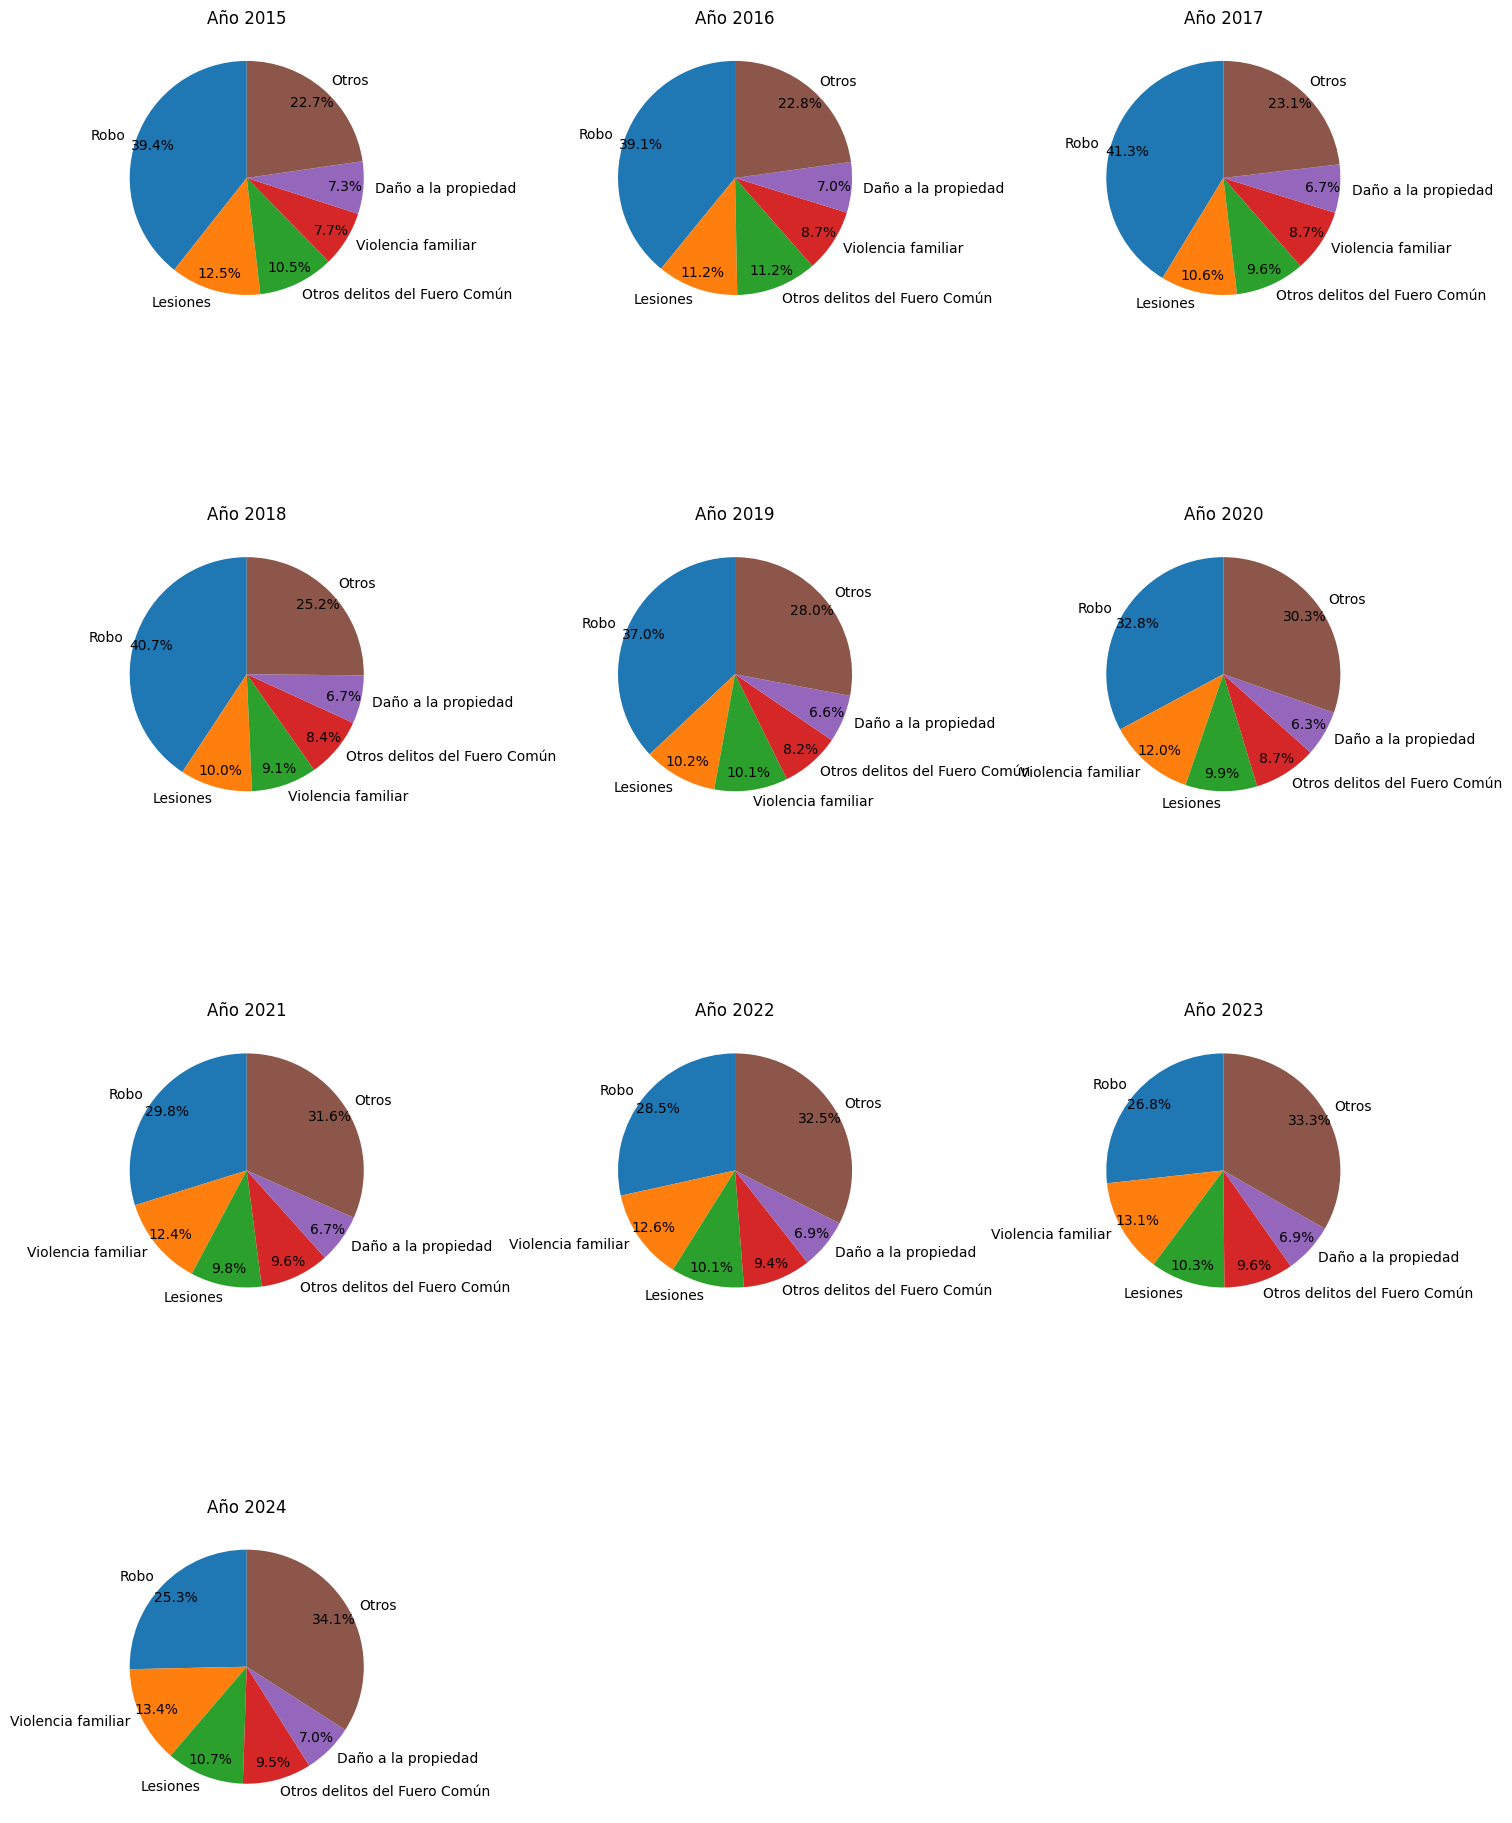

In [98]:
# Preparamos los datos primero
datos_long['frecuencia'] = pd.to_numeric(datos_long['frecuencia'], errors='coerce')
crime_by_year = datos_long.groupby(['anio', 'tipo_de_delito'])['frecuencia'].sum().reset_index()

# Definimos una funcion para limpiar y preparar los datos para un año
def preparar_datos_pie(df_year, top_n=5):
    # Filtramos por frecuencia descendente
    df_year = df_year.sort_values('frecuencia', ascending=False)
    top = df_year.head(top_n).copy()
    if len(df_year) > top_n:
        otros_sum = df_year['frecuencia'].iloc[top_n:].sum()
        otros_row = pd.DataFrame({'tipo_de_delito': ['Otros'], 'frecuencia': [otros_sum]})
        top = pd.concat([top, otros_row], ignore_index=True)
    return top

# Creamos subplots para cada pie
years = sorted(crime_by_year['anio'].unique())
n_years = len(years)

# Definimos el numero de columnas

n_cols = 3
n_rows = (n_years + n_cols - 1) // n_cols

# Creamos las figuras y axiomas
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten() # Simplificamos los indices

# Iteramos por cada año

for i, year in enumerate(years):
    ax = axes[i]
    
    # Usamos los datos para cada año
    year_data = crime_by_year[crime_by_year['anio'] == year]
    if year_data.empty:
        ax.set_visible(False)
        continue

    # Preparamos los datos
    pie_data = preparar_datos_pie(year_data, top_n=5)
    labels = pie_data['tipo_de_delito']
    sizes = pie_data['frecuencia']

    # Dibujamos los "pays"
    ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90,
           labeldistance=1.1, pctdistance=0.85)
    
    ax.set_title(f'Año {year}')

# Escondemos graficas que no usemos
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()
    


---
#### Calcula la tasa por 100,000 habitantes
##### Tasa por 100,000 habitantes
Mostrar el total de delitos en una entidad no nos sirve de mucho. Es mucho más útil calcular la tasa de incidencia delictiva por cada 100,000 habitantes

$$
tasa = \frac{delitos\space totales}{población} \times 100,000
$$

Esta tasa la podemos anualizar multiplicándola por un factor de 12
$$
tasa\space anualizada = tasa \times 12
$$

Población por entidad federativa según [la encuesta intercensal 2015](https://www.inegi.org.mx/programas/intercensal/2015/)

No tienes que descargar nada. Ya están los datos en la carpeta data

In [ ]:
pobs = pd.read_csv('data/poblacion_entidades_2015.csv', encoding='iso-8859-1', sep=";")
pobs = pobs[['Cve_Entidad', 'Entidad', 'Poblacion']]
pobs = pobs.rename(columns={'Cve_Entidad':'clave_entidad', 'Entidad':'entidad', 'Poblacion':'poblacion'})
pobs.head()